# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Проверка гипотезы для Яндекс Книги

- Автор: Каримов Газиз
- Дата: 15.09.2026

## Цели и задачи проекта

**Цель:** с помощью A/B-теста проверить гипотезу: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы

## Описание данных

Для работы предоставлен датасет с активностью пользователей в Москве и Санкт-Петербурге:`/datasets/yandex_knigi_data.csv`

Содержимое датасета:
 - `city` - город
 - `puid` - идентификатор пользователя
 - `hours` - длительность чтения или прослушивания в часах

## Содержимое проекта

1. Загрузка и знакомство с данными
2. Предобработка данных
3. Сравнение выборок
4. Проверка гипотезы
5. Выводы

## Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
# Импортируем библиотеки
import pandas as pd

import matplotlib.pyplot as plt

from scipy import stats as st

from scipy.stats import ttest_ind

In [2]:
# Загружаем датасет
try:
    books_df = pd.read_csv(r'C:\Users\redmi\OneDrive\Рабочий стол\self-education\ЯП\файлы ЯП\файлы для jupyter\yandex_knigi_data.csv')
except FileNotFoundError:
    books_df = pd.read_csv(r'/datasets/yandex_knigi_data.csv')

In [3]:
# Посмотрим на первые строки датасета
books_df.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [4]:
# Выведем общую информацию о датасете
books_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


Итак, содержимое датасета соответствует описанию. Датасет содержит 8784 строк и 4 столбца. Пропусков в данных нет. Данные переведены к корректным типам. Один из столбцов без названия и, скорее всего, представляет собой индекс, продублированный в виде столбца - его можно убрать.

In [5]:
# Удалим безымянный столбец
books_df = books_df.drop('Unnamed: 0',axis=1)
books_df.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


## Предобработка данных

Проверим данные на полные дубликаты

In [6]:
books_df.duplicated().sum()

np.int64(0)

Проверим наличие дубликатов в поле *puid*

In [7]:
books_df.puid.duplicated().sum()

np.int64(244)

244 дубликата. Поскольку на этапе выгрузки данных из базы с помощью SQL выполнялась агрегация по городу и пользователю, наличие продублированных id пользователей говорит о том, выборки Санкт-Петербург и Москва имеют пересечение, что нельзя допускать при проведении A/B-теста. Удалим эти дубликаты.

In [8]:
books_df.drop_duplicates(subset='puid',inplace=True,keep=False)
books_df.puid.duplicated().sum()

np.int64(0)

## Сравнение выборок

7.1 Оценим размеры выборок

In [9]:
msk = len(books_df[books_df['city']=='Москва'])
spb = len(books_df[books_df['city']=='Санкт-Петербург'])

ratio = round(msk/spb,2)

display(f'Число пользователей в Москве: {msk}, число пользователей в Санкт-Петербурге: {spb}, их отношение: {ratio}')

'Число пользователей в Москве: 5990, число пользователей в Санкт-Петербурге: 2306, их отношение: 2.6'

Итак, пользователей в Москве почти в 3 раза больше, чем в СПб.

7.2 Выведем статистику по каждой выборке

In [10]:
msk_group = books_df[books_df['city']=='Москва']
spb_group = books_df[books_df['city']=='Санкт-Петербург']

In [11]:
msk_group['hours'].describe()

count    5990.000000
mean       10.848192
std        36.925622
min         0.000022
25%         0.057042
50%         0.888232
75%         5.933439
max       857.209373
Name: hours, dtype: float64

In [12]:
spb_group['hours'].describe()

count    2306.000000
mean       11.264433
std        39.831755
min         0.000025
25%         0.060173
50%         0.875355
75%         6.138424
max       978.764775
Name: hours, dtype: float64

Видно, что в данных присутствуют аномалии - максимальные значения в каждой выборке слишком большие. Избавимся от них, отфильтровав по 99 процентилю.

In [13]:
msk_group=msk_group[msk_group['hours']<msk_group['hours'].quantile(0.99)]
spb_group=spb_group[spb_group['hours']<spb_group['hours'].quantile(0.99)]

In [14]:
#  Проверим изменения в статистике
msk_group['hours'].describe()

count    5930.000000
mean        8.089568
std        19.823062
min         0.000022
25%         0.055508
50%         0.857040
75%         5.640947
max       153.966600
Name: hours, dtype: float64

In [15]:
spb_group['hours'].describe()

count    2282.000000
mean        8.254132
std        19.283430
min         0.000025
25%         0.056368
50%         0.851330
75%         5.647345
max       146.610567
Name: hours, dtype: float64

7.2 Сравним распределения в выборках

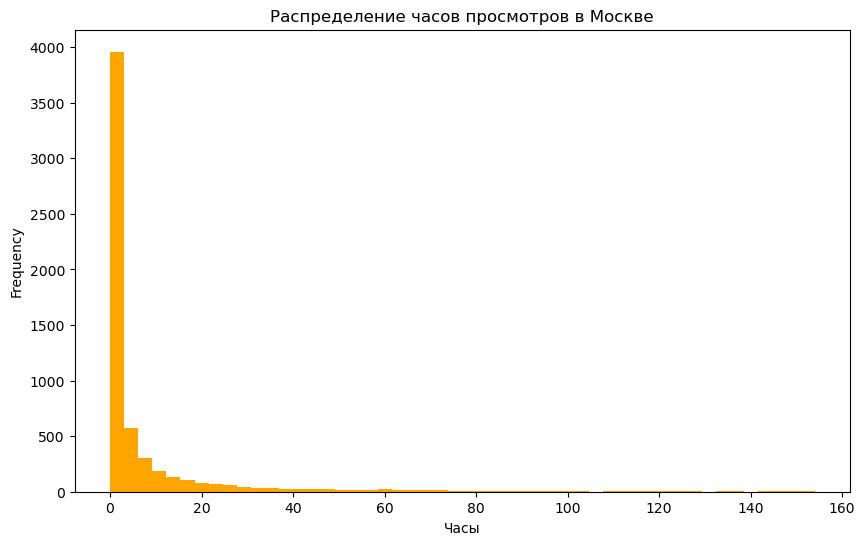

In [16]:
# Построим распределение для Московских пользователей
plt.figure(figsize=(10,6))

msk_group['hours'].plot(kind='hist',bins = 50,
                       color='orange')

plt.xlabel('Часы')
plt.title('Распределение часов просмотров в Москве')

plt.show()

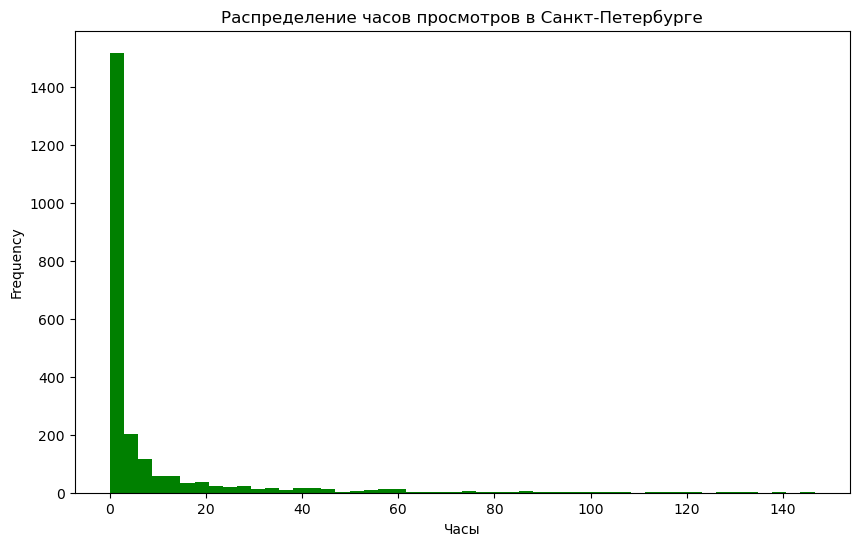

In [17]:
plt.figure(figsize=(10,6))

spb_group['hours'].plot(kind='hist',bins = 50,
                       color='green')

plt.xlabel('Часы')
plt.title('Распределение часов просмотров в Санкт-Петербурге')

plt.show()

Анализ статистики показал следующее:
 - выборки имеют расхождение в стандартной ошибке почти на 1.5 ед.
 - средние значения примерно равные (разница около 0.5)
 - распределения часов активности пользователей очень схожи

Поскольку есть различие в стандартных отклонениях, а следовательно и в дисперсиях, при проверке гипотезы во избежание ошибок будет использовать тест Уэлча.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Статистически докажем это, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

### Сравнение целевых метрик

In [18]:
# Посчитаем целевую метрику (средняя активность в часах) для каждой группы
value_msk = msk_group['hours'].mean()
value_spb = spb_group['hours'].mean()

# Посчитаем разницу в значениях
difference = round(value_msk - value_spb,2)

display(f'Среднее количество часов активности в Москве: {value_msk}, в Санкт-Петербурге: {value_spb}. Разница составила: {difference}')

'Среднее количество часов активности в Москве: 8.089568147346645, в Санкт-Петербурге: 8.254131718774246. Разница составила: -0.16'

Таким образом, в Санкт-Петербурге в среднем пользователи проводят больше времени в приложении. Далее проведем оценку, насколько это различие статистически обосновано.

### Оценка статистической значимости

Оценку проведем с помощью теста Уэлча.

In [19]:
metric_msk = msk_group['hours']
metric_spb = spb_group['hours']

alpha = 0.05 # Уровень значимости

result = st.ttest_ind(
    metric_msk,
    metric_spb,
    equal_var= False,
    alternative = 'less'
    )
print(f'р-значение: {result.pvalue}')

if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нулевую гипотезу отвергнуть нельзя')

р-значение: 0.36553471228993617
Нулевую гипотезу отвергнуть нельзя


Таким образом, полученное различие в целевой метрике статистически значимо.

## 3. Аналитическая записка

В работе проверялась следующая гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы

Для решения поставленной задачи были выполнены следующие шаги:
 - проверка исходных данных на наличие пропусков и дубликатов. Анализ не выявил пропуски, однако были обнаружены пользователи, которые присутствовали в обеих выборках - такие дубликаты были удалены;
 - сравнение статистик сравниваемых групп: анализ выявил аномальные значения по количеству проведенных часов в приложении - такие показатели могут исказить результаты теста, поэтому данные были отфильтрованы по 99-му процентилю; для полученных выборок значения стандартных отклонений различались почти на 1.5 ед.; распределения исследуемой величины в обеих группах схожи; 
 - для проверки гипотезы был выбран тест Уэлча, чтобы избежать дополнительной проверки значимости различия выборочных дисперсий;
 - р-значение = 1.6774856184863766e-05, что сильно меньше принятого уровня значимости 0.05;

**Вывод:** 
результат показал, что различие между целевыми метриками в выборках статистически значимо, следовательно, пользователи в Санкт-Петербурге в среднем более активны, чем пользователи в Москве.

Сложно сказать, с чем именно это связано: на результат может влиять средний возраст пользователей (возможно, взрослые чаще предпочитают книги, чем молодые), особенности региона (например, в СПб люди дольше тратят время на дорогу), привычки/интересы пользователей.

----

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.



**Цель:** оценить эффективность изменения интерфейса сайта интернет-магазина по результатам A/B-теста.

**Проверяемая гипотеза:** упрощение интерфейса приведёт к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на три процентных пункта.

**Описание данных:**

Таблица **participants** с участниками теста:
 - `user_id` - идентификатор пользователя;
 - `group` - группа пользователя;
 - `ab_test` - название теста;
 - `device` - устройство, с которого происходила регистрация.

Таблица **events** - события за 2020 год:
 - `user_id` - идентификатор пользователя;
 - `event_dt` - дата и время события;
 - `event_name` - тип события;
 - `details` - дополнительные данные о событии

**Дополнительные сведения по А/В-тесту:** 

Параметры теста:

- название теста: interface_eu_test;
- группы: А (контрольная), B (новый интерфейс).

## 2. Загрузите данные, оцените их целостность.


In [20]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [21]:
# Посмотрим на данные
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [22]:
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


Выведем общую информацию по каждому датасету

In [23]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [24]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


Итак, мы видим что в обоих датасетах в ключевых столбцах отсутствуют пропуски, а содержимое и типы данных соответствуют описанию.

Поскольку ключевая метрика теста - это конверсия зарегистрированных пользователей в покупателей, для дальнейшего анализа нужно определить как в таблице `events` отмечаются покупки пользователей (регистрация - это registration). Для этого выведем список уникальных значений столбца `event_name`

In [25]:
events_list = events['event_name'].unique()

events_list

array(['End of Black Friday Ads Campaign', 'registration', 'product_page',
       'login', 'product_cart', 'purchase',
       'Start of Christmas&New Year Promo',
       'Start of CIS New Year Gift Lottery'], dtype=object)

Итак, регистрация пользователей записывается как registration, а покупка - purchase

Для дальнейшей работы объединим датасеты в один

In [26]:
df = participants.merge(events, on = 'user_id', how = 'inner')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104558 entries, 0 to 104557
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     104558 non-null  object        
 1   group       104558 non-null  object        
 2   ab_test     104558 non-null  object        
 3   device      104558 non-null  object        
 4   event_dt    104558 non-null  datetime64[ns]
 5   event_name  104558 non-null  object        
 6   details     27878 non-null   object        
dtypes: datetime64[ns](1), object(6)
memory usage: 5.6+ MB


Таким образом, рабочий датафрейм содержит 104558 строк и 7 столбцов

## 3. По таблице `participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

**Проверка соответствия требованиям технического задания**

In [27]:
# Отфильтруем данные по названию теста
ab_test_participants = df[df['ab_test']=='interface_eu_test']

ab_test_participants.head()

,user_id,group,ab_test,device,event_dt,event_name,details
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38
1,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:49,login,NaN
2,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:57,login,NaN
3,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:38:54,login,NaN
4,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:35,login,NaN


In [28]:
ab_test_participants.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79715 entries, 0 to 104557
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     79715 non-null  object        
 1   group       79715 non-null  object        
 2   ab_test     79715 non-null  object        
 3   device      79715 non-null  object        
 4   event_dt    79715 non-null  datetime64[ns]
 5   event_name  79715 non-null  object        
 6   details     21075 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 4.9+ MB


Итак, пропусков нет, а датафрейм уменьшился в объеме.

**Оценим равномерность распределения выборок**

In [29]:
# Посчитаем количество пользователей по группам
group_a = ab_test_participants.loc[ab_test_participants['group']== 'A']
group_b = ab_test_participants.loc[ab_test_participants['group']== 'B']

count_a = group_a.groupby('group')['user_id'].nunique().reset_index()
count_b = group_b.groupby('group')['user_id'].nunique().reset_index()

print(f'В группе А число пользователей: {count_a.iloc[0,1]}, в группе В: {count_b.iloc[0,1]}, относительная разница: {1 - count_a.iloc[0,1] / count_b.iloc[0,1]:.2%}')

В группе А число пользователей: 5383, в группе В: 5467, относительная разница: 1.54%


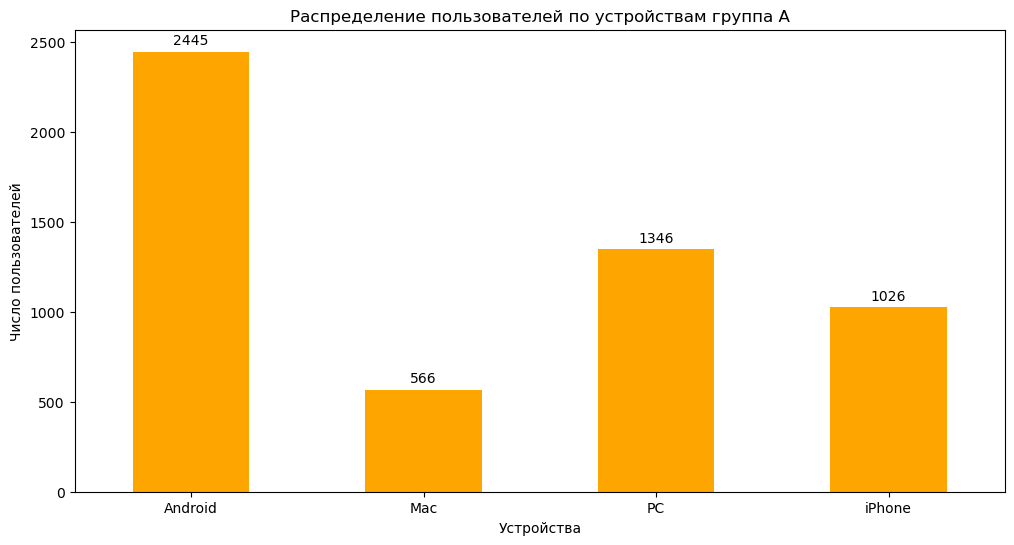

In [30]:
# Оценим распределение выборок по устройствам
# Группа А
group_a_devices = group_a.groupby('device')['user_id'].nunique()

plt.figure(figsize = (12,6))

ax = group_a_devices.plot(kind='bar',
                    color = 'orange',
                    title = 'Распределение пользователей по устройствам группа А',
                    xlabel = 'Устройства',
                    ylabel= 'Число пользователей',
                    rot = 0)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',
                fontsize=10,
                xytext=(0, 3), textcoords='offset points')

plt.show()

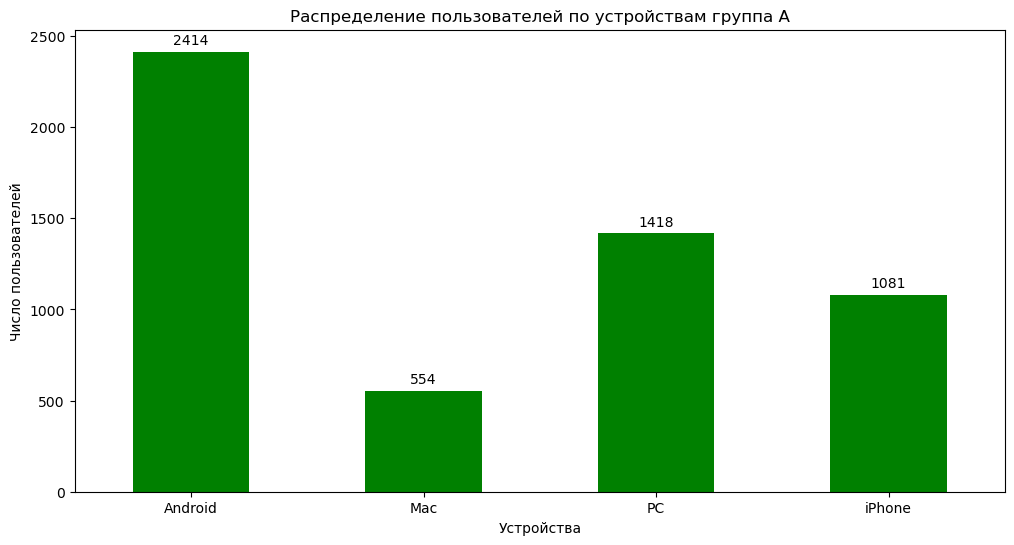

In [31]:
# Оценим распределение выборок по устройствам
# Группа B
group_b_devices = group_b.groupby('device')['user_id'].nunique()

plt.figure(figsize = (12,6))

ax = group_b_devices.plot(kind='bar',
                    color = 'green',
                    title = 'Распределение пользователей по устройствам группа А',
                    xlabel = 'Устройства',
                    ylabel= 'Число пользователей',
                    rot = 0)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',
                fontsize=10,
                xytext=(0, 3), textcoords='offset points')

plt.show()

Сравнение графиков для каждой группы показывает, что распределение пользователей по устройствам примерно равное, следовательно, искажений в тесте по этому критерию быть не должно

**Найдем пересечение двух выборок**

In [32]:
find_intersection = ab_test_participants.groupby('user_id',as_index = False)['group'].nunique()

ab_users = find_intersection[find_intersection['group']>1]

ab_users

,user_id,group


Таким образом, пользователей, которые присутствуют в обеих группах, нет.

3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

**Отфильтруем датасет по целевым действиям (регистрация и покупка)**

In [33]:
ab_test_participants = ab_test_participants[(ab_test_participants['event_name']== 'registration'
                                            )|(
                                            ab_test_participants['event_name']== 'purchase')]
ab_test_participants.head()

,user_id,group,ab_test,device,event_dt,event_name,details
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38
17,001064FEAAB631A1,A,interface_eu_test,Android,2020-12-20 14:12:45,registration,-2.14
35,001E72F50D1C48FA,A,interface_eu_test,Mac,2020-12-17 15:44:05,registration,-3.61
42,002412F1EB3F6E38,B,interface_eu_test,Mac,2020-12-09 09:36:50,registration,-0.48
50,002540BE89C930FB,B,interface_eu_test,Android,2020-12-08 18:06:07,registration,-2.38


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

**Отфильтруем датасет по действиям пользователей, совершенным до верхней даты исследования (крайняя дата регистрации + 7 дней)**

In [34]:
# Создадим столбец с датой: дата регистрации + 7 дней для каждой строки
registration_df = ab_test_participants.loc[ab_test_participants['event_name'] == 'registration'].copy()

registration_df['upper_date_limit'] = registration_df['event_dt'] + pd.Timedelta(days=7)

test_df = ab_test_participants.merge(registration_df[['user_id','upper_date_limit']],on='user_id',how = 'inner')

test_df

,user_id,group,ab_test,device,event_dt,event_name,details,upper_date_limit
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38,2020-12-14 04:37:31
1,001064FEAAB631A1,A,interface_eu_test,Android,2020-12-20 14:12:45,registration,-2.14,2020-12-27 14:12:45
2,001E72F50D1C48FA,A,interface_eu_test,Mac,2020-12-17 15:44:05,registration,-3.61,2020-12-24 15:44:05
3,002412F1EB3F6E38,B,interface_eu_test,Mac,2020-12-09 09:36:50,registration,-0.48,2020-12-16 09:36:50
4,002540BE89C930FB,B,interface_eu_test,Android,2020-12-08 18:06:07,registration,-2.38,2020-12-15 18:06:07
...,...,...,...,...,...,...,...,...
21070,FFE7FC140521F5F6,A,interface_eu_test,PC,2020-12-26 14:37:21,purchase,4.49,2020-12-30 09:10:16
21071,FFE7FC140521F5F6,A,interface_eu_test,PC,2020-12-26 14:37:51,purchase,4.49,2020-12-30 09:10:16
21072,FFEFC0E55C1CCD4F,A,interface_eu_test,PC,2020-12-13 23:52:15,registration,0.0,2020-12-20 23:52:15
21073,FFF28D02B1EACBE1,B,interface_eu_test,PC,2020-12-16 08:23:56,registration,-0.45,2020-12-23 08:23:56


In [35]:
# Отфильтруем покупки пользователей по верхней дате исследования
purchase_df = test_df[test_df['event_name']=='purchase']

purchase_df = purchase_df[purchase_df['event_dt']<=purchase_df['upper_date_limit']]

# Отдельно сохраним датафрейм только с регистрациями
registration_df = test_df[test_df['event_name']=='registration']

# Объединим строки с регистрациями и покупками
filt_df = pd.concat([registration_df,purchase_df],ignore_index=True)

filt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17473 entries, 0 to 17472
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           17473 non-null  object        
 1   group             17473 non-null  object        
 2   ab_test           17473 non-null  object        
 3   device            17473 non-null  object        
 4   event_dt          17473 non-null  datetime64[ns]
 5   event_name        17473 non-null  object        
 6   details           17473 non-null  object        
 7   upper_date_limit  17473 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(6)
memory usage: 1.1+ MB


Таким образом, после всех фильтраций, датасет для дальнейшего анализа содержит 17473 строки.

Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

**Рассчитаем необходимый размер выборки**

In [36]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1-beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03*p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


Таким образом, необходимый размер каждой выборки почти в 8 раз больше, чем фактические размеры групп А и В (примерно по 5,5 тыс.)

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [49]:
# Общее количество пользователей
group_a = filt_df.loc[filt_df['group']== 'A'].copy()
group_b = filt_df.loc[filt_df['group']== 'B'].copy()

count_a = group_a['user_id'].nunique()
count_b = group_b['user_id'].nunique()

# Количество покупателей
num_customers_a = group_a[group_a['event_name']=='purchase']['user_id'].nunique()
num_customers_b = group_b[group_b['event_name']=='purchase']['user_id'].nunique()

- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

In [52]:
# Посчитаем целевую метрику для каждой группы
conversion_a = round(num_customers_a/count_a,2)
conversion_b = round(num_customers_b/count_b,2)

# Посчитаем разницу между метриками
diff = round(conversion_a - conversion_b,2)

display(f'Группа А: всего пользователей:{count_a}, из них покупателей {num_customers_a}. Группа В всего пользователей:{count_b}, из них покупателей {num_customers_b}. Разница в значении: {diff}')

'Группа А: всего пользователей:5383, из них покупателей 1480. Группа В всего пользователей:5467, из них покупателей 1600. Разница в значении: -0.02'

По предварительной оценке разница в целевой метрике составляет 2% в пользу тестовой группы.

## 4. Оценка результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

In [50]:
# Создадим для каждой группы столбец с бинарным значением: 1 - сделал покупку; 0 - не сделал покупку

# Группа А
group_a['made_purchase'] = 0

list_customers_a = list(group_a[group_a['event_name'] == 'purchase']['user_id'].unique())

group_a.loc[group_a['user_id'].isin(list_customers_a),'made_purchase']=1

test_group_a=group_a.drop_duplicates(subset = 'user_id')['made_purchase']

test_group_a = test_group_a.reset_index(drop=True)

test_group_a

0       0
1       0
2       1
3       0
4       0
       ..
5378    1
5379    0
5380    1
5381    0
5382    0
Name: made_purchase, Length: 5383, dtype: int64

In [55]:
# Группа В
group_b['made_purchase'] = 0

list_customers_b = list(group_b[group_b['event_name'] == 'purchase']['user_id'].unique())

group_b.loc[group_b['user_id'].isin(list_customers_b),'made_purchase']=1

test_group_b=group_b.drop_duplicates(subset = 'user_id')['made_purchase']

test_group_b = test_group_b.reset_index(drop=True)

test_group_b

0       0
1       0
2       0
3       0
4       0
       ..
5462    0
5463    0
5464    0
5465    0
5466    0
Name: made_purchase, Length: 5467, dtype: int64

In [57]:
# Проверим результат теста на значимость

# Получим p-value
result = st.ttest_ind(
    test_group_a,
    test_group_b,
    alternative = 'less'
    )
print(f'р-значение: {result.pvalue}')

if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нулевую гипотезу отвергнуть нельзя')

р-значение: 0.0203088631878687
Отвергаем нулевую гипотезу


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?